In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Behavior of default `qm_trapz_indefinite`

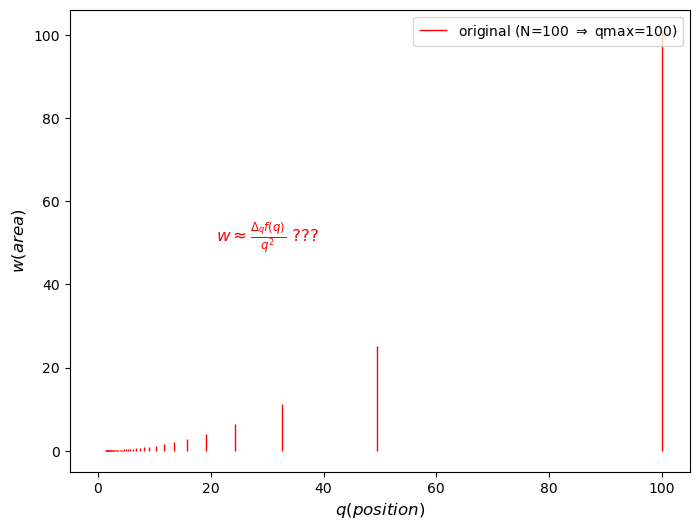

In [ ]:
# This default code samples in 1/x

N1 = 100 #number of samples
x1 = np.zeros(N1)
w1 = np.zeros(N1)
h1 = 1.0/(N1+1.0) #step size in x 
for i in range(N1):
    t1 = h1 + i*h1 # current linear x value 
    f1 = 1.0 # current function value 
    x1[i] = 1.0/t1-1.0 # current sampled value of x ('ish)
    w1[i] = f1*h1/t1/t1 # calculate weight at current x value

plt.figure(figsize=(8, 6))
plt.vlines(x1, 0, w1, colors='r', linestyle='solid', linewidth=1.0, label=r'original (N=100 $\Rightarrow$ qmax=100)')
# plt.vlines(x2, 0, w2, colors='b', linestyles='dashed', linewidth=1.0, label='david (N=200, q=100)')
# plt.vlines(x3, 0, 0.1*w3, colors='g', linestyle='dotted', linewidth=1.0, label=r'$q^3$ (N=200, q=100)')
plt.text(30, 50, r'$w \approx \frac{\Delta_q f(q)}{q^2}$ ???', fontsize=12, color='red', ha='center')
plt.xlabel(r'$q (position)$', fontsize=12)
plt.ylabel(r'$w (area)$', fontsize=12)
plt.legend()

# Adding David modification to $q_{max}$

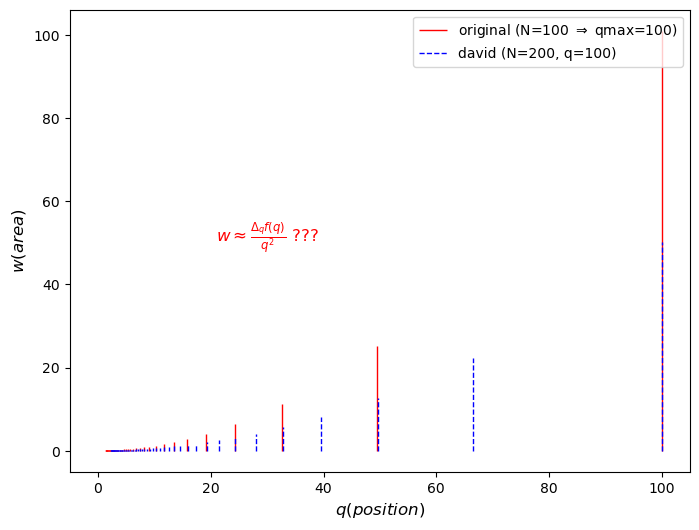

In [ ]:
# Let's keep the 1/x sampling, but enforce a maximum q value

qmax2 = 100
N2 = 200
x2 = np.zeros(N2)
w2 = np.zeros(N2)
h2 = 1.0/(qmax2+1.0)
for i in range(N2):
    t2 = h2 + (qmax2-1)/(N2-1)*i*h2
    y2 = 1.0
    x2[i] = 1.0/t2-1.0
    w2[i] = y2*(qmax2-1)/(N2-1)*h2/t2/t2

plt.figure(figsize=(8, 6))
plt.vlines(x1, 0, w1, colors='r', linestyle='solid', linewidth=1.0, label=r'original (N=100 $\Rightarrow$ qmax=100)')
plt.vlines(x2, 0, w2, colors='b', linestyles='dashed', linewidth=1.0, label='david (N=200, q=100)')
# plt.vlines(x3, 0, 0.1*w3, colors='g', linestyle='dotted', linewidth=1.0, label=r'$q^3$ (N=200, q=100)')
plt.text(30, 50, r'$w \approx \frac{\Delta_q f(q)}{q^2}$ ???', fontsize=12, color='red', ha='center')
plt.xlabel(r'$q (position)$', fontsize=12)
plt.ylabel(r'$w (area)$', fontsize=12)
plt.legend()

# Adding scalable sampling spacing

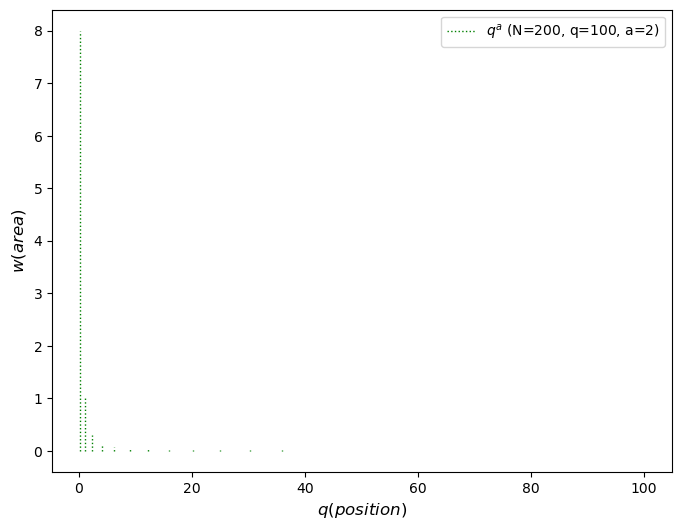

In [92]:
# Let's enforce a max q, and also a number of samples, but sample in q^a where now a=-1 (i.e. 1/q sampling) is not fixed. 

qmax3 = 100 
N3 = 20
x3 = np.zeros(N3)
t3 = np.zeros(N3)
w3 = np.zeros(N3)
a = 2
dt = (np.power(qmax3, 1/a)/N3)
for i in range(N3):
    t3[i] = (i+1) * dt # current linear step in [0,qmax^(1/a)]
    x3[i] = np.power(t3[i], a) # re-sample in q^a
    #y3 = F[np.power(x3[i], a)] # current function value
    y3 = 1.0
    w3[i] = y3 * np.power(t3[i], -2*a) * a * np.power(t3[i], a-1) * dt

plt.figure(figsize=(8, 6))
# plt.vlines(x1, 0, w1, colors='r', linestyle='solid', linewidth=1.0, label=r'original (N=100 $\Rightarrow$ qmax=100)')
# plt.vlines(x2, 0, w2, colors='b', linestyles='dashed', linewidth=1.0, label='david (N=200, q=100)')
plt.vlines(x3, 0, w3, colors='g', linestyle='dotted', linewidth=1.0, label=rf'$q^a$ (N=200, q=100, a={a})')
# plt.text(30, 50, r'$w \approx \frac{\Delta_q f(q)}{q^2}$ ???', fontsize=12, color='red', ha='center')
plt.xlabel(r'$q (position)$', fontsize=12)
plt.ylabel(r'$w (area)$', fontsize=12)
plt.legend()

In [94]:
print(t3)
print(x3)
print(w3)
print(np.diff(x3))

[ 0.5  1.   1.5  2.   2.5  3.   3.5  4.   4.5  5.   5.5  6.   6.5  7.
  7.5  8.   8.5  9.   9.5 10. ]
[  0.25   1.     2.25   4.     6.25   9.    12.25  16.    20.25  25.
  30.25  36.    42.25  49.    56.25  64.    72.25  81.    90.25 100.  ]
[8.00000000e+00 1.00000000e+00 2.96296296e-01 1.25000000e-01
 6.40000000e-02 3.70370370e-02 2.33236152e-02 1.56250000e-02
 1.09739369e-02 8.00000000e-03 6.01051841e-03 4.62962963e-03
 3.64132909e-03 2.91545190e-03 2.37037037e-03 1.95312500e-03
 1.62833299e-03 1.37174211e-03 1.16635078e-03 1.00000000e-03]
[0.75 1.25 1.75 2.25 2.75 3.25 3.75 4.25 4.75 5.25 5.75 6.25 6.75 7.25
 7.75 8.25 8.75 9.25 9.75]
